# 01 - Exploratory Data Analysis

## Objective
This notebook explores the student performance dataset and prepares the foundation for a fee defaulter prediction system.

I'm working with an academic dataset, so this notebook also documents how academic and family-related variables may be use to construct a fee-default risk target.

In [1]:
import os
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsa

# Download latest version
path = kagglehub.dataset_download("devansodariya/student-performance-data")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

100%|██████████| 7.16k/7.16k [00:00<00:00, 4.85MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/devansodariya/student-performance-data/versions/1
Files: ['student_data.csv']


In [2]:
files = [f for f in os.listdir(path) if f.endswith(".csv")]
files

['student_data.csv']

In [3]:
student_data = pd.read_csv(os.path.join(path, files[0]))
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
student_data.shape

(395, 33)

In [5]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
student_data.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [7]:
student_data.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [8]:
student_data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
keep_cols = [
    "sex",
    "age",
    "address",
    "famsize",
    "Pstatus",
    "Medu",
    "Fedu",
    "Mjob",
    "Fjob",
    "traveltime",
    "studytime",
    "failures",
    "schoolsup",
    "famsup",
    "paid",
    "higher",
    "internet",
    "famrel",
    "absences",
    "G1",
    "G2",
    "G3"
]

In [10]:
drop_cols = [
    "school",
    "reason",
    "guardian",
    "activities",
    "nursery",
    "romantic",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

In [11]:
student_data_model = student_data[keep_cols].copy()
student_data_model.shape

(395, 22)

## Feature Relevance Filtering

The dataset contains 33 variables with no missing values. Since the project goal is to build a fee-defaulter risk prediction system using an academic dataset, variables were filtered based on their relevance to financial risk proxy modeling.

Kept variables fall into four groups:

1. Socioeconomic and family context:
Examples are parental education, parental job, family size, parental cohabitation status.

2. Access and support indicators: Examples are internet access, travel time, school support and family support.

3. Academic engagement annd performance: Examples are study time, absences, failures, G1, G2, G3.

4. Behaviourial or continuation indicators: Examples are paid classes and desire  for higher education.

In [12]:
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Target Design: Fee-Default Risk Proxy

This dataset does not contain a direct school-free default column. Therefore, the target for this project will be engineered as a proxy for fee-default risk.

The logic is based on the assumption that students with persistent academic struggle, repeated failures, and high absenteeism may also face broader financial or stability-related  challenges thaat increase the risk of fee default.

This does not mean poor performance directly causes fee defalt. Instead, the target serves as a practical risk indicator for a portfolio project where direct financial payment recordds are unavailable.

The engineered target will be called 'default', where:
- '1' = higher fee-default risk
- '0' = lower fee-default risk

The initial rule-based proxy will use:
- low final performances ('G3')
- repeated failures ('failures')
- high absenteeism ('absences')

This target design choice will be revisited later during feature engineering and thresholding analysis.



In [13]:
student_data_model[["failures", "absences", "G1", "G2", "G3"]].describe()

,failures,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.334177,5.708861,10.908861,10.713924,10.415190
std,0.743651,8.003096,3.319195,3.761505,4.581443
min,0.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,0.000000,8.000000,9.000000,8.000000
50%,0.000000,4.000000,11.000000,11.000000,11.000000
75%,0.000000,8.000000,13.000000,13.000000,14.000000
max,3.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
student_data_model['default'] =(
    (student_data_model['G3'] < 10) |
    (student_data_model['failures'] >= 2) |
    (student_data_model['absences'] > 15)
).astype(int)

student_data_model["default"].value_counts()


,count
default,
0,240
1,155


In [15]:
student_data_model["default"].value_counts(normalize=True)

,proportion
default,
0,0.607595
1,0.392405


## Initial Target Review

The engineered 'default' varible provides a first approximation of fee-default risk based on academic and attendance-related distress signals.

This is a synthetic target created for modeling purposes, not an observed financial outcome. Its usefulness depends on whether the resulting class distribution is reasonable and whether the model later learns meaningful patterns from the selected features.

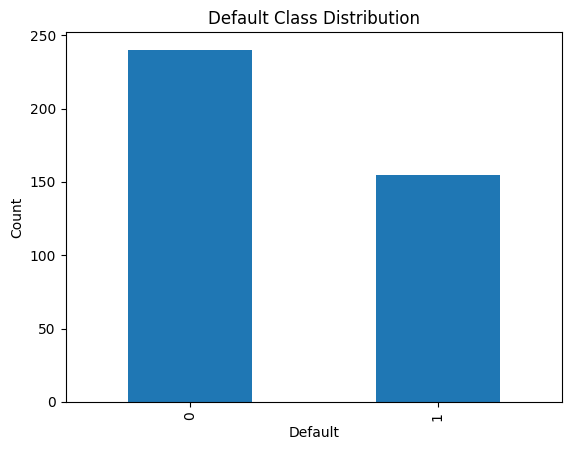

In [16]:
student_data_model['default'].value_counts().plot( kind='bar', title="Default Class Distribution")
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

## Target Distribution Check

The engineered target shows a target distriibution of approximately 60.8% low-risk and 39.2 high-risk students.

This is reasonably balanced for an initial classification task, meaning the dataset contains enough examples from both classes to support model training without severe imbalance concerns at this stage.

In [17]:
categorical_cols = (
    "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob", "schoolsup", "famsup", "paid", "higher", "internet"
)
for col in categorical_cols:
  print(f"\n=== {col} ===")
  print(student_data_model[col].value_counts())


=== sex ===
sex
F    208
M    187
Name: count, dtype: int64

=== address ===
address
U    307
R     88
Name: count, dtype: int64

=== famsize ===
famsize
GT3    281
LE3    114
Name: count, dtype: int64

=== Pstatus ===
Pstatus
T    354
A     41
Name: count, dtype: int64

=== Mjob ===
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

=== Fjob ===
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

=== schoolsup ===
schoolsup
no     344
yes     51
Name: count, dtype: int64

=== famsup ===
famsup
yes    242
no     153
Name: count, dtype: int64

=== paid ===
paid
no     214
yes    181
Name: count, dtype: int64

=== higher ===
higher
yes    375
no      20
Name: count, dtype: int64

=== internet ===
internet
yes    329
no      66
Name: count, dtype: int64


In [18]:
numerical_cols = [
    "age", "Fedu", "Medu", "traveltime", "studytime", "failures", "famrel", "absences", "G1", "G2", "G3"
]
for num in numerical_cols:
  print(f"\n=== {num} ===")
  print(student_data_model[num].value_counts())


=== age ===
age
16    104
17     98
18     82
15     82
19     24
20      3
22      1
21      1
Name: count, dtype: int64

=== Fedu ===
Fedu
2    115
3    100
4     96
1     82
0      2
Name: count, dtype: int64

=== Medu ===
Medu
4    131
2    103
3     99
1     59
0      3
Name: count, dtype: int64

=== traveltime ===
traveltime
1    257
2    107
3     23
4      8
Name: count, dtype: int64

=== studytime ===
studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64

=== failures ===
failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

=== famrel ===
famrel
4    195
5    106
3     68
2     18
1      8
Name: count, dtype: int64

=== absences ===
absences
0     115
2      65
4      53
6      31
8      22
10     17
14     12
12     12
3       8
7       7
16      7
18      5
5       5
20      4
13      3
15      3
1       3
22      3
9       3
11      3
28      1
24      1
54      1
25      1
56      1
26      1
75      1
21      1
19      1
30      1
38 

In [19]:
student_data_model.groupby("default")[numerical_cols].mean().T

default,0,1
age,16.470833,17.045161
Fedu,2.637500,2.341935
Medu,2.854167,2.587097
traveltime,1.412500,1.503226
studytime,2.104167,1.929032
failures,0.066667,0.748387
famrel,3.979167,3.890323
absences,3.862500,8.567742
G1,12.487500,8.464516
G2,12.733333,7.587097


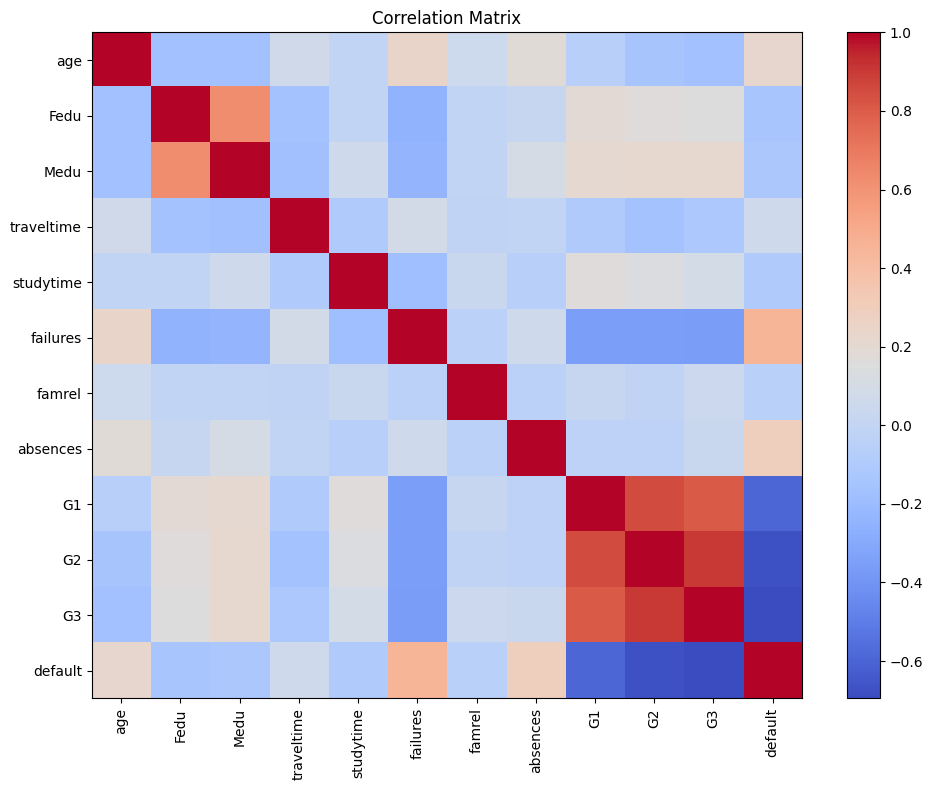

In [22]:
corr = student_data_model[numerical_cols + ["default"]].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

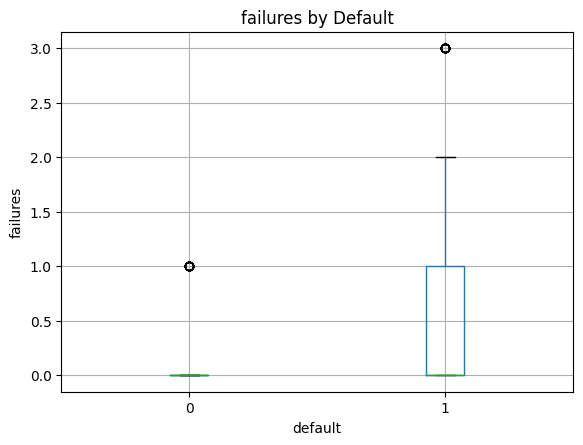

<Figure size 600x400 with 0 Axes>

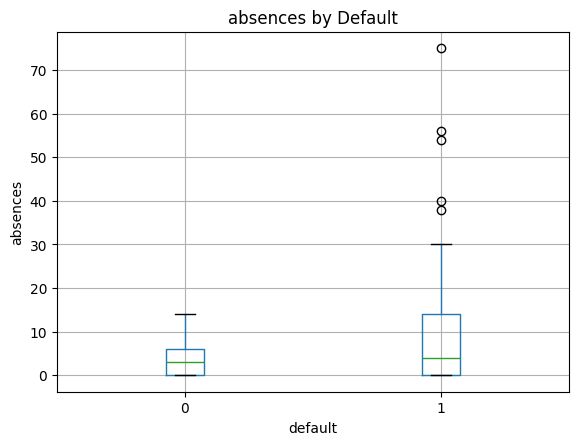

<Figure size 600x400 with 0 Axes>

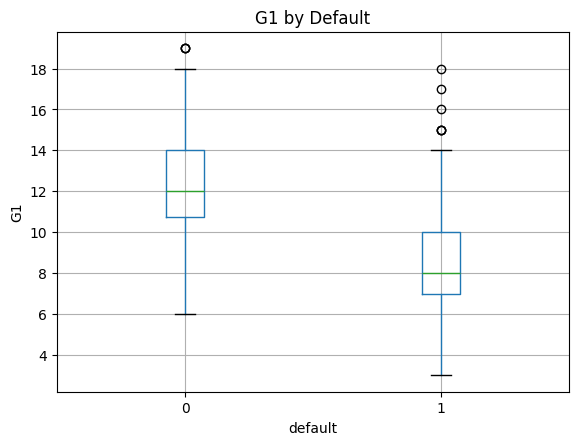

<Figure size 600x400 with 0 Axes>

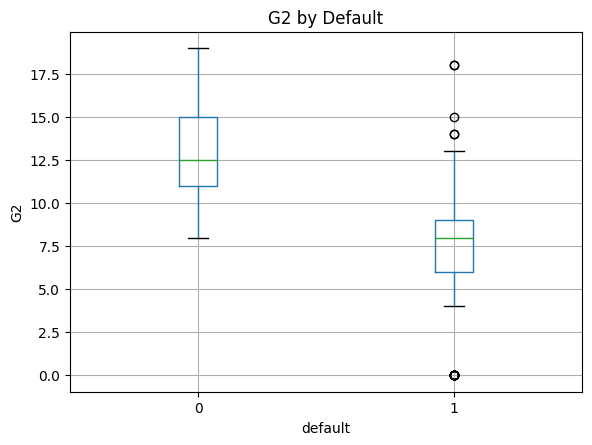

<Figure size 600x400 with 0 Axes>

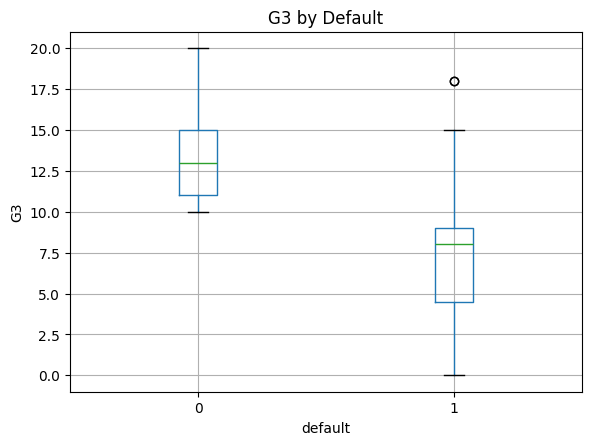

In [23]:
important_numeric = ["failures", "absences", "G1", "G2", "G3"]

for col in important_numeric:
  plt.figure(figsize=(6, 4))
  student_data_model.boxplot(column=col, by="default")
  plt.title(f"{col} by Default")
  plt.suptitle("")
  plt.xlabel("default")
  plt.ylabel(col)
  plt.show()

### Interpretation of Early EDA Results

The engineered target show meaningful relationships with the selected academic distress variables.

Students in the higher-risk ('default = 1') group generally have:
- lower first, second, and final grades
- more prior failures
- higher absenteeism

However, it is important to note that the target was partially constructed using 'G3', 'failures', and'absences'. Therefore, strong relationships between these variables and the target are expected and should be interpreted as part of the target-design logic rather than as independent discovery.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
from pathlib import Path
import numpy as pd
import pandas as pd

project_root = Path("/content/drive/MyDrive/fee_defaulter_prediction")

# create folders if they don't already exist
(project_root / "data" / "processed").mkdir(parents=True, exist_ok=True)

print(project_root)

/content/drive/MyDrive/fee_defaulter_prediction


In [30]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

project_root = Path("/content/drive/MyDrive/fee-defaulter-prediction")
(project_root / "data" / "processed").mkdir(parents=True, exist_ok=True)

output_path = project_root / "data" / "processed" / "01_eda_output.csv"
student_data_model.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/fee-defaulter-prediction/data/processed/01_eda_output.csv
